<a href="https://colab.research.google.com/github/MahekLasi028/DSBDAL/blob/main/MINIPROJECT2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
df = pd.read_csv("/content/sample_data/covid_vaccine_statewise.csv")

In [24]:
print("--- Dataset Description ---")
print(df.describe())

--- Dataset Description ---
       Total Doses Administered      Sessions        Sites   \
count              7.621000e+03  7.621000e+03   7621.000000   
mean               9.188171e+06  4.792358e+05   2282.872064   
std                3.746180e+07  1.911511e+06   7275.973730   
min                7.000000e+00  0.000000e+00      0.000000   
25%                1.356570e+05  6.004000e+03     69.000000   
50%                8.182020e+05  4.547000e+04    597.000000   
75%                6.625243e+06  3.428690e+05   1708.000000   
max                5.132284e+08  3.501031e+07  73933.000000   

       First Dose Administered  Second Dose Administered  \
count             7.621000e+03              7.621000e+03   
mean              7.414415e+06              1.773755e+06   
std               2.995209e+07              7.570382e+06   
min               7.000000e+00              0.000000e+00   
25%               1.166320e+05              1.283100e+04   
50%               6.614590e+05              

In [25]:
state_df = df[df['State'] != 'India']
latest_state_data = state_df.groupby('State')[['First Dose Administered', 'Second Dose Administered']].max().reset_index()

In [26]:
print("\n--- State-wise Vaccination Totals ---")
print(latest_state_data.head())


--- State-wise Vaccination Totals ---
                         State  First Dose Administered  \
0  Andaman and Nicobar Islands                 216046.0   
1               Andhra Pradesh               17628583.0   
2            Arunachal Pradesh                 692475.0   
3                        Assam               10495293.0   
4                        Bihar               23350171.0   

   Second Dose Administered  
0                   94597.0  
1                 6214312.0  
2                  186619.0  
3                 2208577.0  
4                 4484768.0  


In [27]:
india_totals = df[df['State'] == 'India'].max()
male_vaccinated = india_totals['Male(Individuals Vaccinated)']
female_vaccinated = india_totals['Female(Individuals Vaccinated)']

In [28]:
print(f"\nTotal Males Vaccinated: {int(male_vaccinated)}")
print(f"Total Females Vaccinated: {int(female_vaccinated)}")


Total Males Vaccinated: 134941971
Total Females Vaccinated: 115668447


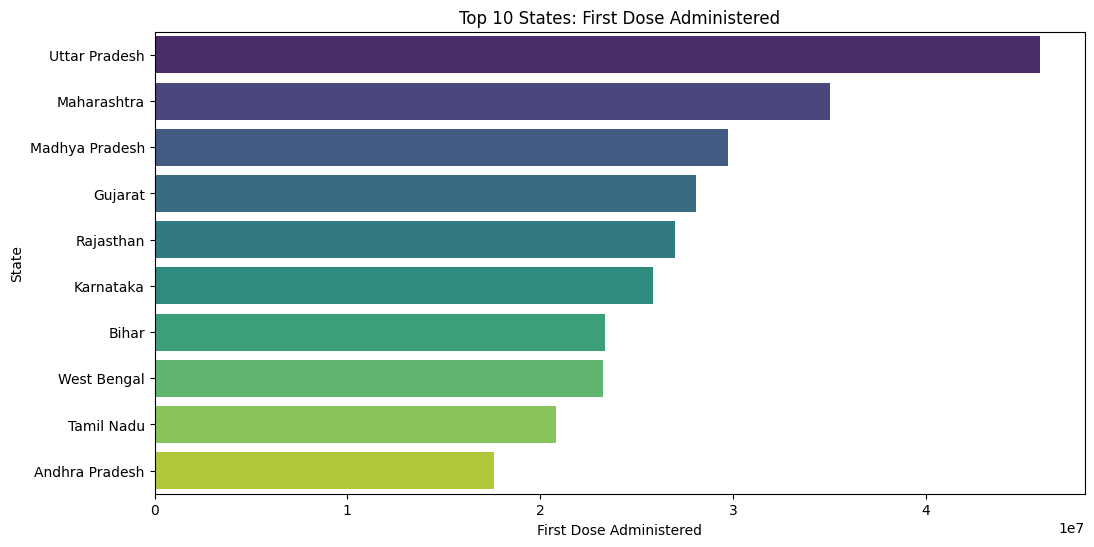

In [29]:
plt.figure(figsize=(12, 6))
top_10 = latest_state_data.nlargest(10, 'First Dose Administered')
sns.barplot(x='First Dose Administered', y='State', data=top_10, hue='State', palette='viridis', legend=False)
plt.title('Top 10 States: First Dose Administered')
plt.show()

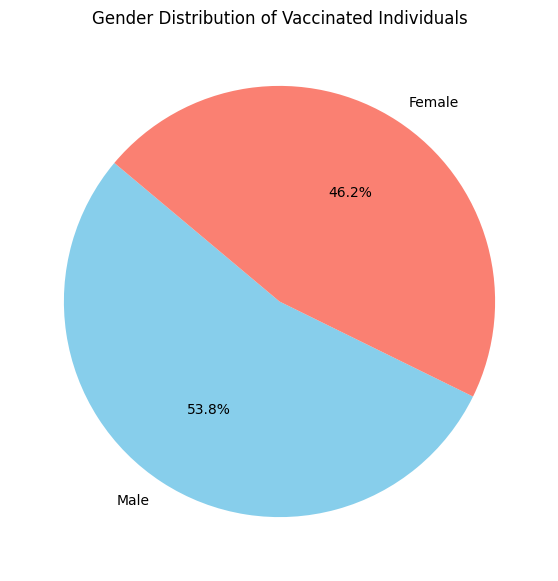

In [30]:
plt.figure(figsize=(7, 7))
plt.pie([male_vaccinated, female_vaccinated], labels=['Male', 'Female'], autopct='%1.1f%%', colors=['skyblue', 'salmon'], startangle=140)
plt.title('Gender Distribution of Vaccinated Individuals')
plt.show()